In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn streamlit joblib

Note: you may need to restart the kernel to use updated packages.


 
# 1: DATA UNDERSTANDING
# EcoType - Forest Cover Type Prediction
 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots show inside the notebook
%matplotlib inline

print("All libraries imported successfully")

All libraries imported successfully


# Load the dataset

In [9]:
df = pd.read_csv('../data/forest_cover.csv')

print("Dataset loaded successfully!")
print(f"Shape of dataset: {df.shape}")

Dataset loaded successfully!
Shape of dataset: (145890, 13)


# See the first 5 rows

In [12]:
print("=== FIRST 5 ROWS ===")
df.head()

=== FIRST 5 ROWS ===


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


# Column Names & Data Types

In [15]:
# Check column names and their data types

print("=== COLUMN INFO ===")
df.info()

=== COLUMN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area    

# Statistical Summary

In [18]:
# Statistical summary of all numeric columns

print("=== STATISTICAL SUMMARY ===")
df.describe()

=== STATISTICAL SUMMARY ===


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


# Check for Missing Values

In [21]:
# Check how many missing values each column has

print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values in entire dataset: {df.isnull().sum().sum()}")

=== MISSING VALUES ===
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64

Total missing values in entire dataset: 0


# Check for Duplicate Rows

In [24]:
# Check for duplicate records

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 0


# Check Target Variable (Cover_Type)

In [27]:
# How many samples per forest cover type?

print(" === TARGET VARIABLE: Cover_Type ===")
print(df['Cover_Type'].value_counts())
print(f"\nNumber of unique classes: {df['Cover_Type'].nunique()}")

 === TARGET VARIABLE: Cover_Type ===
Cover_Type
Lodgepole Pine       103071
Spruce/Fir            31110
Aspen                  3069
Krummholz              2160
Ponderosa Pine         2160
Douglas-fir            2160
Cottonwood/Willow      2160
Name: count, dtype: int64

Number of unique classes: 7


# Visualize Class Distribution

C:\Users\nihmath\AppData\Local\Temp\ipykernel_8488\1153140344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cover_Type', data=df, palette='viridis',


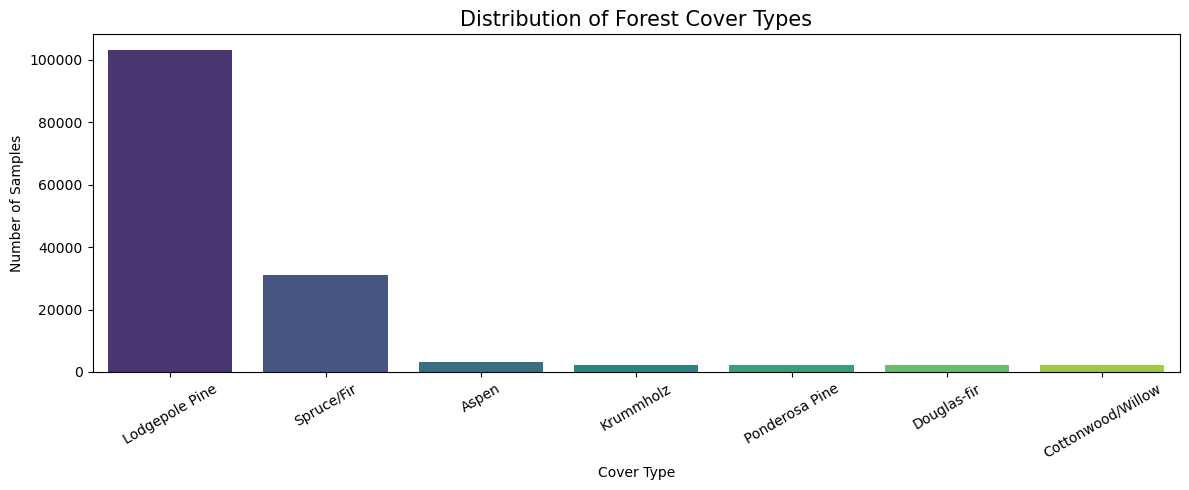

In [41]:
# Bar chart of forest cover type counts
plt.figure(figsize=(12, 5))
sns.countplot(x='Cover_Type', data=df, palette='viridis',
              order=df['Cover_Type'].value_counts().index)
plt.title('Distribution of Forest Cover Types', fontsize=15)
plt.xlabel('Cover Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Map Cover Type Numbers to Names

In [43]:
# Cover_Type already contains text names — no mapping needed!
# Let's just count each class directly

print("=== COVER TYPE DISTRIBUTION ===")
cover_counts = df['Cover_Type'].value_counts()

for name, count in cover_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{name}: {count} samples ({percentage:.2f}%)")

print(f"\nTotal samples: {len(df)}")
print(f"Number of classes: {df['Cover_Type'].nunique()}")

=== COVER TYPE DISTRIBUTION ===
Lodgepole Pine: 103071 samples (70.65%)
Spruce/Fir: 31110 samples (21.32%)
Aspen: 3069 samples (2.10%)
Krummholz: 2160 samples (1.48%)
Ponderosa Pine: 2160 samples (1.48%)
Douglas-fir: 2160 samples (1.48%)
Cottonwood/Willow: 2160 samples (1.48%)

Total samples: 145890
Number of classes: 7


# Check Unique Values in Categorical Columns

In [46]:
# Wilderness_Area and Soil_Type are categorical
# Let's see how many unique values they have

print("Wilderness_Area unique values:", df['Wilderness_Area'].nunique())
print(df['Wilderness_Area'].value_counts())

print("\nSoil_Type unique values:", df['Soil_Type'].nunique())
print(df['Soil_Type'].value_counts())

Wilderness_Area unique values: 4
Wilderness_Area
1    134367
3      6349
4      4675
2       499
Name: count, dtype: int64

Soil_Type unique values: 39
Soil_Type
29    60696
12    29144
30    18158
23    10150
20     6098
16     2219
24     2169
10     2142
18     1829
39     1210
9      1112
19     1046
3       962
22      931
4       843
38      803
40      736
32      690
6       650
2       623
33      616
17      612
13      476
11      406
1       356
31      332
8       179
14      169
5       165
7       105
35      102
26       54
37       34
34       22
21       16
27       15
36       10
28        9
25        1
Name: count, dtype: int64


## 📝 Summary from Notebook 1

- Dataset has 145,891 rows and 13 columns
- Target variable: Cover_Type (7 classes — Spruce/Fir, Lodgepole Pine, 
  Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz)
- Missing values: 0 — dataset has no missing values
- Duplicates: 0 — no duplicate rows found
- Class imbalance: YES — severe! 
    - Most common: Lodgepole Pine (103,071 samples = 70.6%)
    - Least common: Krummholz, Ponderosa Pine, Douglas-fir, 
      Cottonwood/Willow (2,160 samples each = 1.5%)
- Wilderness_Area and Soil_Type are categorical — need encoding later
- Next step: Notebook 2 - Data Cleaningata Cleaning